# AES-128 Analysis — ChipWhisperer / STM32F303 project

A single place that ties together everything built in this project:

1. **AES-128 correctness** — the FIPS 197 known-answer vector and round-trip.
2. **Diffusion / avalanche** — how one input bit spreads across the rounds.
3. **Fault propagation** — how a single injected byte fault spreads (the
   `aes_fi_demo` model).
4. **Giraud DFA** — recovering the full key from single-bit last-round faults
   (the `giraud_attack` code).
5. **Power traces** — inspecting the captured ChipWhisperer traces and a
   correlation-power-analysis (CPA) methodology walk-through.

Everything uses the project's own pure-Python AES (`aes_reference`), the fault
demo (`demo`), and the attack (`giraud`), so the notebook runs with the base
environment (NumPy + Matplotlib) — no ChipWhisperer or PyCryptodome needed.

> These are offline analyses for study. The power-analysis section works on
> already-captured data and does not drive hardware.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Resolve project paths relative to this notebook (analysis/).
ROOT = Path.cwd().parent if Path.cwd().name == 'analysis' else Path.cwd()
FI_DEMO = ROOT / 'fault_injection' / 'aes_fi_demo'
GIRAUD = ROOT / 'fault_injection' / 'giraud_attack'
RESULTS = ROOT / 'experiments' / 'chipwhisperer_aes' / 'results'
for p in (FI_DEMO, GIRAUD):
    sys.path.insert(0, str(p))

import aes_reference as aes
import demo
import giraud

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
KEY = bytes.fromhex('000102030405060708090a0b0c0d0e0f')
PLAINTEXT = bytes.fromhex('00112233445566778899aabbccddeeff')
print('Project root:', ROOT)
print('Capture campaigns found:', sorted(p.name for p in RESULTS.glob('*')) if RESULTS.exists() else 'none')

Matplotlib is building the font cache; this may take a moment.


Project root: C:\Projetos\PFE 5A
Capture campaigns found: ['20260922T075513_440347Z', '20260923T090630_498123Z', '20260928T070657_976291Z']


## 1. AES-128 correctness

The public FIPS 197 example: key `000102...0e0f`, plaintext `001122...eeff`,
ciphertext `69c4e0...c55a`. This is the same vector the firmware checks after
flashing.

In [2]:
ct = aes.AES(KEY).encrypt_block(PLAINTEXT)
pt_back = aes.AES(KEY).decrypt_block(ct)
print('plaintext       ', PLAINTEXT.hex())
print('ciphertext      ', ct.hex())
print('decrypt(ciphert)', pt_back.hex())
assert ct.hex() == '69c4e0d86a7b0430d8cdb78070b4c55a'
assert pt_back == PLAINTEXT
print('\nKnown-answer test: PASS   |   Round-trip: PASS')

plaintext        00112233445566778899aabbccddeeff
ciphertext       69c4e0d86a7b0430d8cdb78070b4c55a
decrypt(ciphert) 00112233445566778899aabbccddeeff

Known-answer test: PASS   |   Round-trip: PASS


### The AES state as a 4x4 byte matrix

AES works on a 16-byte block laid out column by column: byte index
`i = 4*column + row`. Below is the plaintext and the ciphertext in that layout.

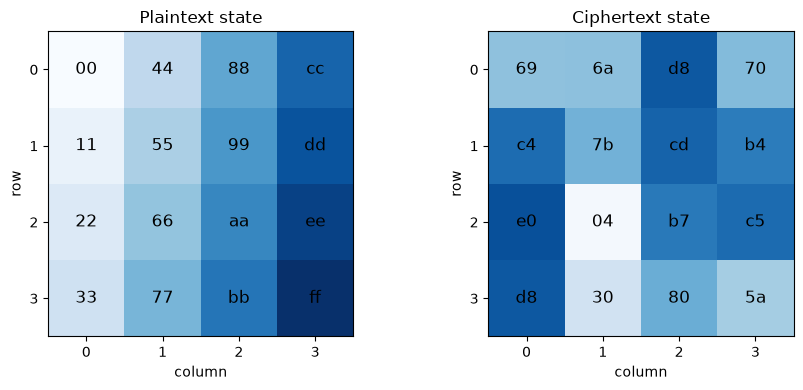

In [3]:
def state_grid(ax, data, title):
    m = np.array([[data[4*c + r] for c in range(4)] for r in range(4)])
    ax.imshow(m, cmap='Blues', vmin=0, vmax=255)
    for r in range(4):
        for c in range(4):
            ax.text(c, r, f'{m[r, c]:02x}', ha='center', va='center', fontsize=12)
    ax.set_title(title); ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xlabel('column'); ax.set_ylabel('row'); ax.grid(False)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
state_grid(axes[0], PLAINTEXT, 'Plaintext state')
state_grid(axes[1], ct, 'Ciphertext state')
plt.tight_layout(); plt.show()

### The S-box

SubBytes replaces every byte through this fixed 16x16 lookup table — the only
non-linear part of AES.

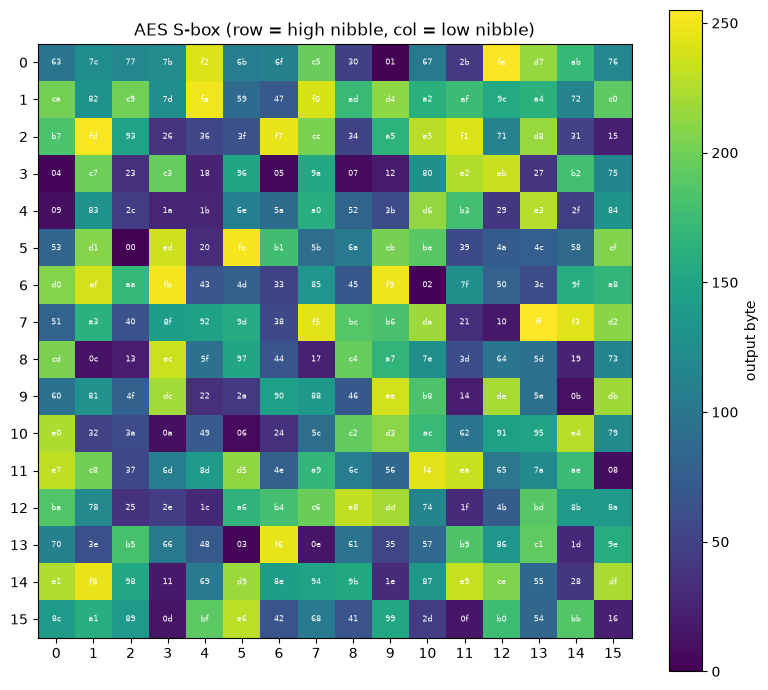

In [4]:
sbox = np.array(aes.s_box).reshape(16, 16)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sbox, cmap='viridis')
for r in range(16):
    for c in range(16):
        ax.text(c, r, f'{sbox[r, c]:02x}', ha='center', va='center', fontsize=6, color='w')
ax.set_title('AES S-box (row = high nibble, col = low nibble)')
ax.set_xticks(range(16)); ax.set_yticks(range(16)); ax.grid(False)
plt.colorbar(im, label='output byte'); plt.tight_layout(); plt.show()

## 2. Diffusion — the avalanche effect

Flip a single bit of the plaintext and watch how many **state bits** differ from
the unmodified encryption after every operation. A good cipher reaches ~50% of
128 bits (full diffusion) within a couple of rounds.

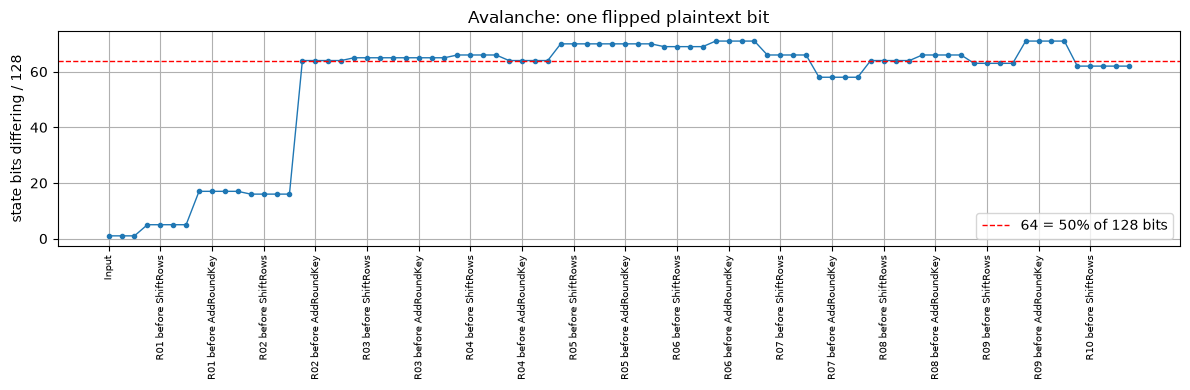

Bits differing at the final ciphertext: 62 / 128


In [5]:
def trace_states(key, plaintext):
    _, tr = demo.encrypt_trace(key, plaintext, None)
    return tr  # list of {'label','state'(16 bytes)}

base = trace_states(KEY, PLAINTEXT)
flipped_pt = bytes([PLAINTEXT[0] ^ 0x01]) + PLAINTEXT[1:]  # flip 1 bit of byte 0
other = trace_states(KEY, flipped_pt)

labels = [s['label'] for s in base]
bit_diffs = [sum(bin(a ^ b).count('1') for a, b in zip(x['state'], y['state']))
             for x, y in zip(base, other)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(bit_diffs, marker='.', lw=1)
ax.axhline(64, color='r', ls='--', lw=1, label='64 = 50% of 128 bits')
ax.set_xticks(range(0, len(labels), 4))
ax.set_xticklabels([labels[i] for i in range(0, len(labels), 4)], rotation=90, fontsize=7)
ax.set_ylabel('state bits differing / 128'); ax.set_title('Avalanche: one flipped plaintext bit')
ax.legend(); plt.tight_layout(); plt.show()
print('Bits differing at the final ciphertext:', bit_diffs[-1], '/ 128')

## 3. Fault propagation

Inject **one** byte-level XOR just before an operation (the `aes_fi_demo` model)
and measure how many bytes and bits differ from the clean run at each step.
The default — round 9, before MixColumns, `0x01` on byte (0,0) — is the classic
DFA setup: MixColumns spreads the single-byte difference across a whole column.

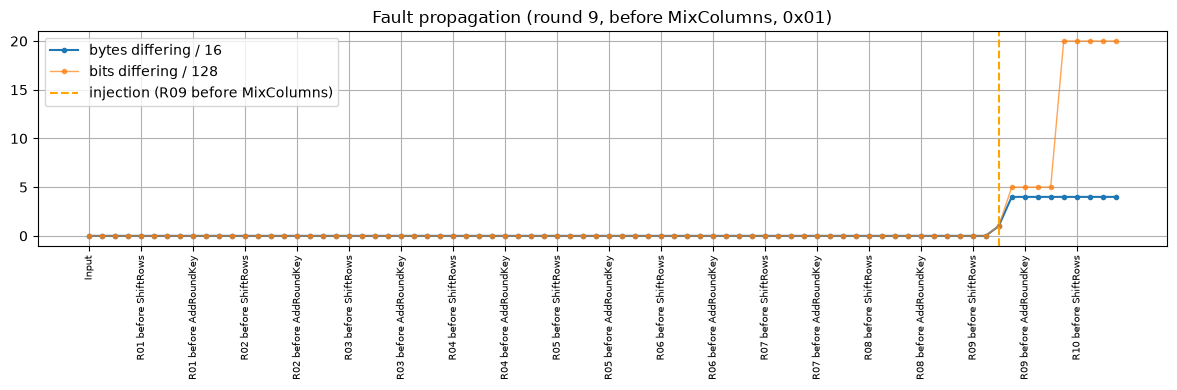

Clean  ciphertext: 69c4e0d86a7b0430d8cdb78070b4c55a
Faulty ciphertext: 1bc4e0d86a7b04a5d8cd58807083c55a
Ciphertext XOR   : 72000000000000950000ef0000370000
Differing output bytes: 4


In [6]:
def fault_propagation(fault):
    ct_clean, clean = demo.encrypt_trace(KEY, PLAINTEXT, None)
    ct_faulty, faulty = demo.encrypt_trace(KEY, PLAINTEXT, fault)
    steps = demo.compare(clean, faulty)
    return ct_clean, ct_faulty, steps

fault = demo.Fault(round=9, stage='MixColumns', row=0, column=0, mask=0x01)
ct_clean, ct_faulty, steps = fault_propagation(fault)
labels = [s['label'] for s in steps]
bytes_changed = [s['bytes_changed'] for s in steps]
bits_changed = [s['bits_changed'] for s in steps]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(bytes_changed, marker='o', ms=3, label='bytes differing / 16')
ax.plot(bits_changed, marker='.', lw=1, label='bits differing / 128', alpha=0.7)
inj = next(i for i, s in enumerate(steps) if s['bytes_changed'] > 0)
ax.axvline(inj, color='orange', ls='--', label=f'injection ({labels[inj]})')
ax.set_xticks(range(0, len(labels), 4))
ax.set_xticklabels([labels[i] for i in range(0, len(labels), 4)], rotation=90, fontsize=7)
ax.set_title('Fault propagation (round 9, before MixColumns, 0x01)')
ax.legend(); plt.tight_layout(); plt.show()
print('Clean  ciphertext:', ct_clean.hex())
print('Faulty ciphertext:', ct_faulty.hex())
print('Ciphertext XOR   :', bytes(a ^ b for a, b in zip(ct_clean, ct_faulty)).hex())
print('Differing output bytes:', sum(a != b for a, b in zip(ct_clean, ct_faulty)))

### Where does the fault land in the ciphertext?

Compare the injection round. A fault **before round-9 MixColumns** spreads to 4
output bytes; a fault **before round-10 SubBytes** (the Giraud model) touches a
single output byte. That single-byte behaviour is what makes key recovery
tractable in the next section.

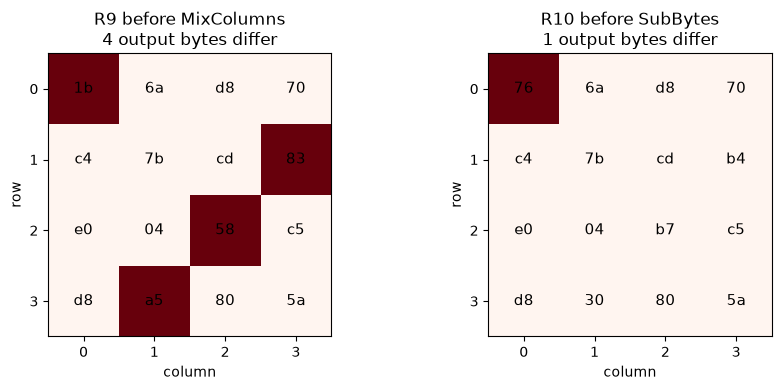

In [7]:
scenarios = [
    ('R9 before MixColumns', demo.Fault(9, 'MixColumns', 0, 0, 0x01)),
    ('R10 before SubBytes',  demo.Fault(10, 'SubBytes', 0, 0, 0x01)),
]
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (name, flt) in zip(axes, scenarios):
    cc, cf, _ = fault_propagation(flt)
    diff = np.array([[1 if cc[4*c+r] != cf[4*c+r] else 0 for c in range(4)] for r in range(4)])
    ax.imshow(diff, cmap='Reds', vmin=0, vmax=1)
    for r in range(4):
        for c in range(4):
            ax.text(c, r, f'{cf[4*c+r]:02x}', ha='center', va='center', fontsize=11)
    ax.set_title(f'{name}\n{int(diff.sum())} output bytes differ')
    ax.set_xlabel('column'); ax.set_ylabel('row'); ax.grid(False)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
plt.tight_layout(); plt.show()

## 4. Giraud differential fault attack

Recover the full AES-128 key from single-bit faults at the input of the last
round. See [`docs/giraud-attack`](../docs/giraud-attack/README.md) for the
theory. Here we run it and visualise two things:

- the **ShiftRows permutation** (which input byte reaches which ciphertext byte),
- how the **candidate set** for one key byte shrinks as faults accumulate.

In [8]:
k10 = giraud.recover_last_round_key(KEY, PLAINTEXT)
recovered = giraud.invert_key_schedule(k10)
print('Recovered round-10 key:', k10.hex())
print('Recovered master key  :', recovered.hex())
print('Actual master key     :', KEY.hex())
print('Key recovery:', 'SUCCESS' if recovered == KEY else 'FAILED')

Recovered round-10 key: 13111d7fe3944a17f307a78b4d2b30c5
Recovered master key  : 000102030405060708090a0b0c0d0e0f
Actual master key     : 000102030405060708090a0b0c0d0e0f
Key recovery: SUCCESS


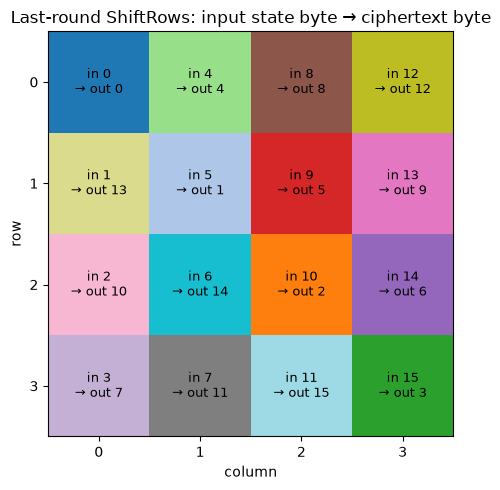

In [9]:
# Map each input state byte (row,col) to the ciphertext byte it faults.
correct = giraud.encrypt(KEY, PLAINTEXT)
perm = np.full((4, 4), -1)
for col in range(4):
    for row in range(4):
        faulty = giraud.fault_ciphertext(KEY, PLAINTEXT, row, col, 0x01)
        j = next(i for i in range(16) if correct[i] != faulty[i])
        perm[row, col] = j

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(perm, cmap='tab20')
for r in range(4):
    for c in range(4):
        ax.text(c, r, f'in {4*c+r}\n→ out {perm[r, c]}', ha='center', va='center', fontsize=9)
ax.set_title('Last-round ShiftRows: input state byte → ciphertext byte')
ax.set_xlabel('column'); ax.set_ylabel('row'); ax.grid(False)
ax.set_xticks(range(4)); ax.set_yticks(range(4)); plt.tight_layout(); plt.show()

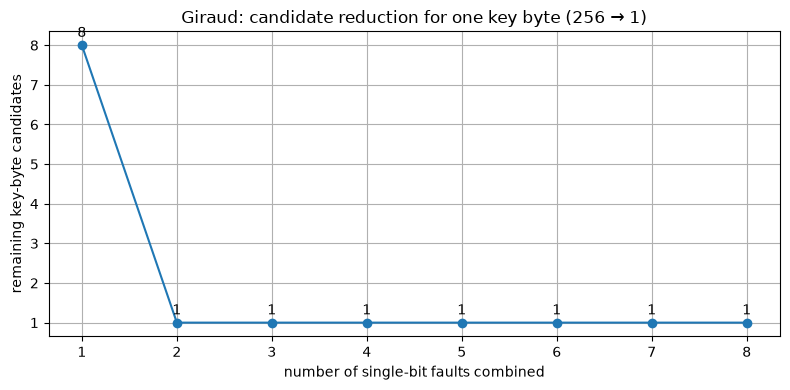

Final candidate: [19] = 0x13


In [10]:
# Candidate-set reduction for the key byte reached from input (0,0).
correct = giraud.encrypt(KEY, PLAINTEXT)
surviving, sizes = None, []
for bit in range(8):
    faulty = giraud.fault_ciphertext(KEY, PLAINTEXT, 0, 0, 1 << bit)
    j = next(i for i in range(16) if correct[i] != faulty[i])
    cand = giraud.candidate_key_bytes(correct, faulty, j)
    surviving = cand if surviving is None else surviving & cand
    sizes.append(len(surviving))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 9), sizes, marker='o')
ax.set_xlabel('number of single-bit faults combined')
ax.set_ylabel('remaining key-byte candidates')
ax.set_title('Giraud: candidate reduction for one key byte (256 → 1)')
for x, y in zip(range(1, 9), sizes):
    ax.annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 6), ha='center')
plt.tight_layout(); plt.show()
print('Final candidate:', sorted(surviving), '= 0x%02x' % next(iter(surviving)))

## 5. Power traces from the ChipWhisperer

Load the captured baseline traces and inspect them. Each `.npz` holds `wave`
(the ADC samples), plus the `plaintext`, `ciphertext`, and `key` used.

Using campaign: 20260928T070657_976291Z
Traces: 10 | samples per trace: 24000
Unique plaintexts: 10


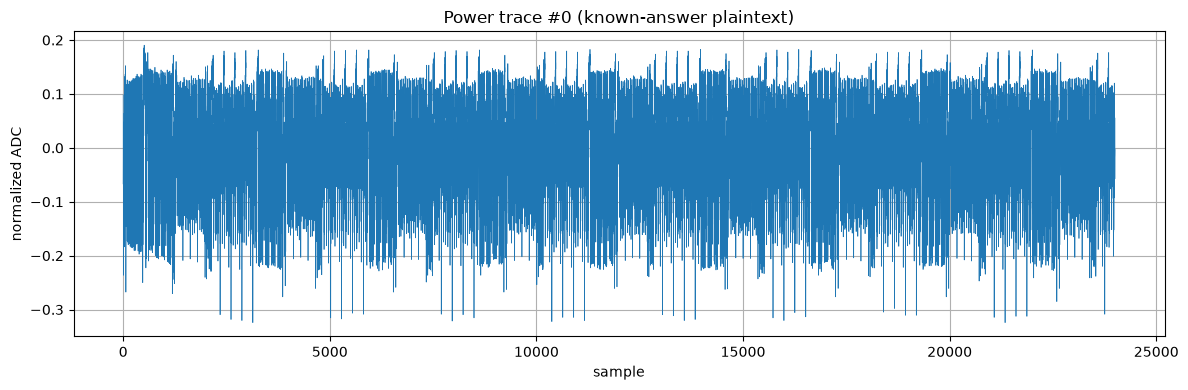

In [11]:
def load_campaign(folder):
    files = sorted(folder.glob('trace_*.npz'))
    waves, pts, cts = [], [], []
    for f in files:
        d = np.load(f)
        waves.append(d['wave']); pts.append(bytes(d['plaintext'])); cts.append(bytes(d['ciphertext']))
    return np.array(waves), pts, cts

campaigns = sorted(RESULTS.glob('*')) if RESULTS.exists() else []
assert campaigns, 'No capture campaigns found under results/.'
waves, pts, cts = load_campaign(campaigns[-1])
print('Using campaign:', campaigns[-1].name)
print('Traces:', waves.shape[0], '| samples per trace:', waves.shape[1])
print('Unique plaintexts:', len(set(pts)))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(waves[0], lw=0.5)
ax.set_title('Power trace #0 (known-answer plaintext)')
ax.set_xlabel('sample'); ax.set_ylabel('normalized ADC'); plt.tight_layout(); plt.show()

### Overlay and per-sample variance

Overlaying all traces and plotting the variance across traces highlights the
samples where the data-dependent activity happens — the interesting region for
side-channel analysis.

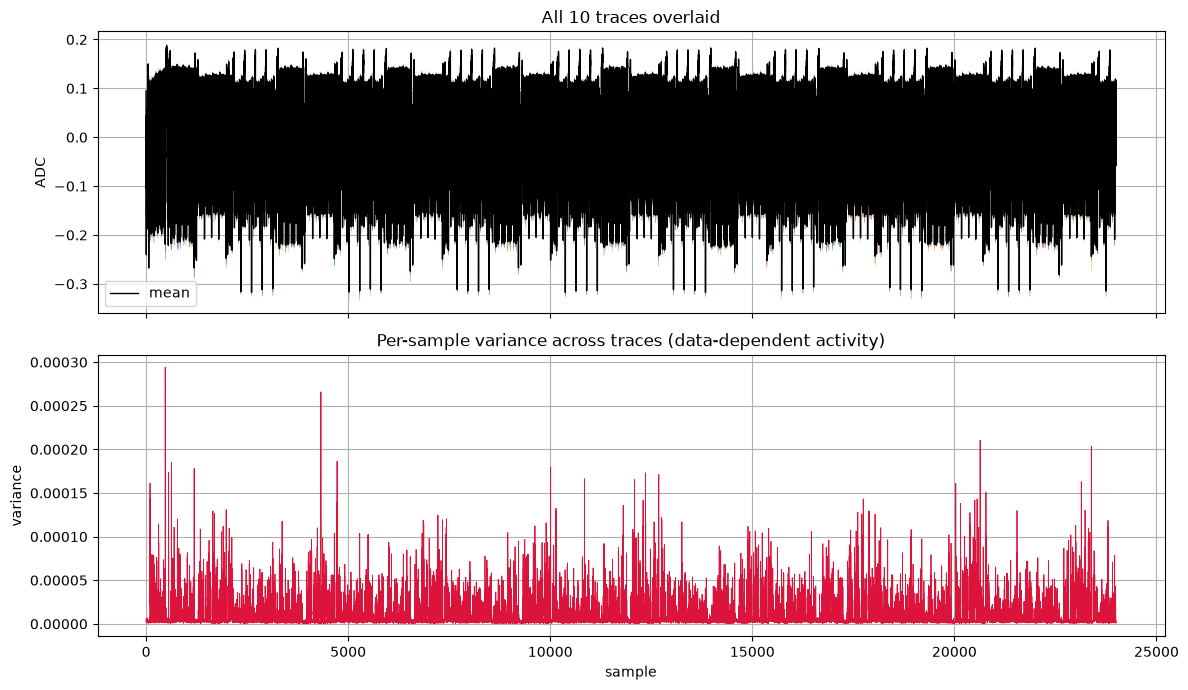

Highest-variance sample: 473


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for w in waves:
    axes[0].plot(w, lw=0.3, alpha=0.5)
axes[0].plot(waves.mean(0), 'k', lw=1, label='mean')
axes[0].set_title(f'All {len(waves)} traces overlaid'); axes[0].legend(); axes[0].set_ylabel('ADC')

var = waves.var(0)
axes[1].plot(var, lw=0.6, color='crimson')
axes[1].set_title('Per-sample variance across traces (data-dependent activity)')
axes[1].set_xlabel('sample'); axes[1].set_ylabel('variance')
plt.tight_layout(); plt.show()
peak = int(var.argmax())
print('Highest-variance sample:', peak)

### CPA methodology — first-round SubBytes leakage

Correlation Power Analysis models the power at the S-box output of round 1 as
its **Hamming weight** and correlates that model, over all traces, against the
measured samples — for each of the 256 guesses of key byte 0. The correct guess
should correlate best.

> **Caveat:** this campaign has only **10 distinct plaintexts**. That is far too
> few for reliable CPA on a real STM32 (tens of well-aligned traces are the
> usual minimum). Treat the result below as a demonstration of the *method* and
> of how to read a correlation ranking — not as a dependable key recovery. To do
> it for real, capture more traces:
> `aes_capture.py capture --traces 100`.

True key byte 0        : 0x00
Best-correlating guess : 0xbd  (rank of true key: 134 / 256)


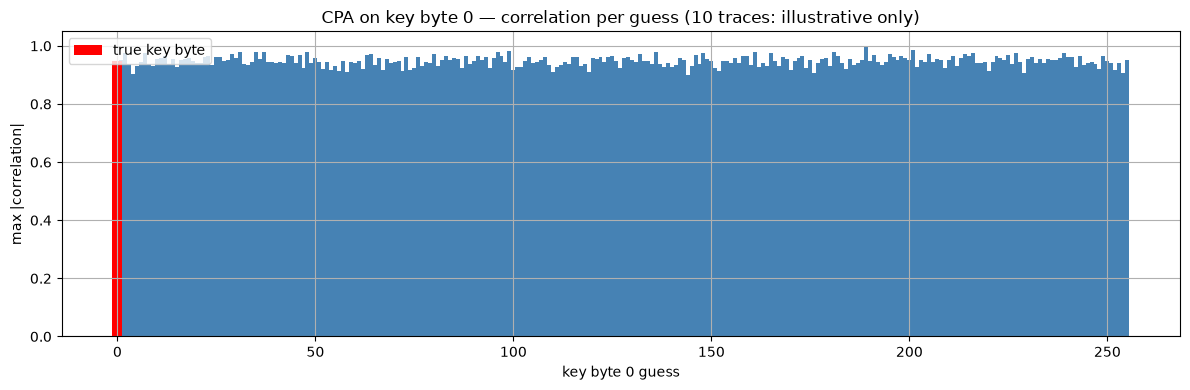

In [13]:
HW = np.array([bin(x).count('1') for x in range(256)])   # Hamming weight table
sbox = np.array(aes.s_box)
P = np.array([p[0] for p in pts])                          # plaintext byte 0 of each trace
traces = waves

def cpa_byte0():
    corr_per_guess = np.zeros(256)
    tn = traces - traces.mean(0)
    tn_ss = np.sqrt((tn ** 2).sum(0))
    for k in range(256):
        model = HW[sbox[P ^ k]].astype(float)             # leakage hypothesis
        mn = model - model.mean()
        denom = np.sqrt((mn ** 2).sum()) * tn_ss
        denom[denom == 0] = 1e-12
        corr = np.abs((mn[:, None] * tn).sum(0) / denom)  # |corr| at every sample
        corr_per_guess[k] = corr.max()
    return corr_per_guess

corr = cpa_byte0()
ranking = np.argsort(corr)[::-1]
true_k0 = KEY[0]
print('True key byte 0        : 0x%02x' % true_k0)
print('Best-correlating guess : 0x%02x  (rank of true key: %d / 256)'
      % (ranking[0], list(ranking).index(true_k0) + 1))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(256), corr, width=1.0, color='steelblue')
ax.bar([true_k0], [corr[true_k0]], width=2.5, color='red', label='true key byte')
ax.set_xlabel('key byte 0 guess'); ax.set_ylabel('max |correlation|')
ax.set_title('CPA on key byte 0 — correlation per guess (10 traces: illustrative only)')
ax.legend(); plt.tight_layout(); plt.show()

## Summary

| Analysis | What it shows | Source in this repo |
| --- | --- | --- |
| Known-answer + round-trip | The AES matches FIPS 197 | `fault_injection/aes_fi_demo/aes_reference.py` |
| Avalanche | One input bit reaches ~half the state in a couple of rounds | this notebook |
| Fault propagation | A single byte fault's spread depends on the round | `aes_fi_demo/demo.py` |
| Giraud DFA | Single-bit last-round faults leak the full key | `fault_injection/giraud_attack/giraud.py` |
| Power traces | Captured ChipWhisperer waveforms and where they vary | `experiments/chipwhisperer_aes/results/` |
| CPA method | How Hamming-weight correlation ranks key guesses | this notebook |

**Honest limitations**

- The FI and DFA sections operate on the software AES model; the same fault
  parameters map to the firmware `f` command, but a software result is not
  evidence of a successful *physical* fault campaign.
- The captured campaigns hold only 10 distinct plaintexts, so the CPA section is
  a methodology demonstration, not a validated key recovery. Capture more traces
  to make it real.